Block size 500: Data restored correctly.
Block size 1500: Data restored correctly.
Block size 2500: Data restored correctly.
Block size 3500: Data restored correctly.
Block size 4500: Data restored correctly.
Block size 5500: Data restored correctly.
Block size 6500: Data restored correctly.
Block size 7500: Data restored correctly.
Block size 8500: Data restored correctly.
Block size 9500: Data restored correctly.
Block size 10500: Data restored correctly.
Block size 11500: Data restored correctly.
Block size 12500: Data restored correctly.
Block size 13500: Data restored correctly.
Block size 14500: Data restored correctly.


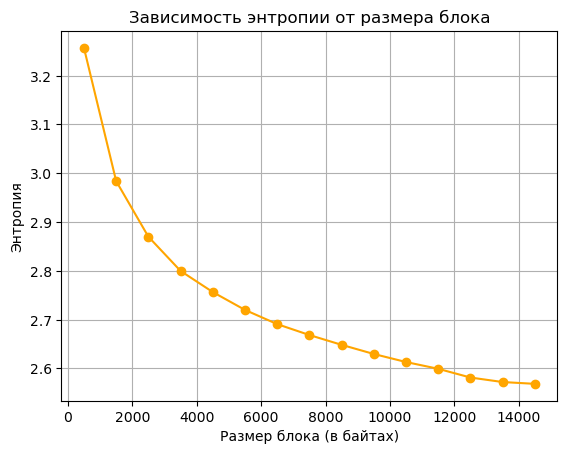

In [2]:
import struct
import math
import numpy as np
import matplotlib.pyplot as plt

# entropy
def entropy(b, size=1):

    d = {}
    for i in range(0, len(b), size):
        block = b[i:i+size]
        d[block] = d.get(block, 0) + 1
    
    H = 0
    lenght = len(b) // size

    for i in d.values():
        if i > 0:
            p_i = i / lenght
            H -= p_i * math.log2(p_i)

    return H

# BWT
def bwt_encode_block(b):
    n = len(b)
    matrix = [b[i:] + b[:i] for i in range(n)]
    matrix.sort()
    orig_index = matrix.index(b)
    last_column = bytes([i[-1] for i in matrix])

    return last_column, orig_index

def bwt_decode_block(last_column, index):
    n = len(last_column)

    count = [0]*256
    for byte in last_column:
        count[byte] += 1
    
    total = 0
    for i in range(256):
        c = count[i]
        count[i] = total
        total += c
    
    next_pos = [0]*n
    current_count = [0]*256
    for i in range(n):
        byte = last_column[i]
        pos = count[byte] + current_count[byte]
        next_pos[i] = pos
        current_count[byte] += 1
    
    result = bytearray()
    row = index
    for i in range(n):
        byte = last_column[row]
        result.append(byte)
        row = next_pos[row]
    
    return bytes(result[::-1])

def bwt_encode(data, block_size=None):
    if block_size is None:
        return bwt_encode_block(data)
    
    num_blocks = (len(data) + block_size - 1) // block_size
    output = struct.pack('<I', num_blocks)
    indices = []
    
    for i in range(0, len(data), block_size):
        chunk = data[i:i+block_size]
        col, idx = bwt_encode_block(chunk)
        indices.append(idx)
        output += struct.pack('<I', idx)
        output += struct.pack('<I', len(col))
        output += col
        
    return output, indices

def bwt_decode(data, index=None, blocked=False):
    if not blocked:
        return bwt_decode_block(data, index)
    
    offset = 0
    num_blocks = struct.unpack('<I', data[offset:offset+4])[0]
    offset += 4
    
    result = bytearray()
    for _ in range(num_blocks):
        idx = struct.unpack('<I', data[offset:offset+4])[0]
        length = struct.unpack('<I', data[offset+4:offset+8])[0]
        offset += 8
        
        block_data = data[offset:offset+length]
        offset += length
        
        result.extend(bwt_decode_block(block_data, idx))
        
    return bytes(result)

# MTF
def mtf_encode(b):
    alphabet = list(range(256))
    result = []

    for byte in b:
        index = alphabet.index(byte)
        result.append(index)
        alphabet.pop(index)
        alphabet.insert(0, byte)
    
    return bytes(result)

def mtf_decode(b):
    alphabet = list(range(256))
    result = []
    
    for index in b:
        byte = alphabet[index]
        result.append(byte)
        alphabet.pop(index)
        alphabet.insert(0, byte)
    
    return bytes(result)


file_path = "C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 1/test_files/test2.txt"
block_sizes = [x for x in range(500,15000,1000)]
entropy_values = []

with open(file_path, 'rb') as f:
        data = f.read()

for chunk_size in block_sizes:
    output = bwt_encode(data, chunk_size)
    data_bwt, idx = output
    
    mtf_data = mtf_encode(data_bwt)
    entropy_ = entropy(mtf_data)
    entropy_values.append(entropy_)

    mtf_decoded = mtf_decode(mtf_data)
    bwt_decoded = bwt_decode(data_bwt, idx, chunk_size)

    if bwt_decoded == data:
        print(f"Block size {chunk_size}: Data restored correctly.")
    else:
        print(f"Block size {chunk_size}: Data restoration failed.")

plt.plot(block_sizes, entropy_values, marker='o',color = 'orange')
plt.xlabel('Размер блока (в байтах)')
plt.ylabel('Энтропия')
plt.title('Зависимость энтропии от размера блока')
plt.grid(True)
plt.show()
